# Overall Comparison: LRU, LRU-K, GBDT, IL variants

Notebook ini membandingkan **LRU, LRU-K, GDBT, IL_no_guard, IL_Guard, IL_drift, IL_drift+guard** pada dua dataset dan semua ukuran cache.

Catatan: Baseline LRU/LRU-K/GDBT/IL_Xu diambil dari ringkasan teks yang sudah ada (results26Jan2026). IL variants diambil dari summary JSON terbaru di `results/`.


In [1]:
import re
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(4):
    if (PROJECT_ROOT / 'results').exists() and (PROJECT_ROOT / 'src').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_ROOT = PROJECT_ROOT / 'results'

DATASETS = {
    'wikipedia_september_2007': RESULTS_ROOT / 'wikipedia_september_2007',
    'wiki2018': RESULTS_ROOT / 'wiki2018',
}

FEATURE_SET = 'A2'
RUN_PREFIX = '001'

FIG_DIR = RESULTS_ROOT / 'figures'
TAB_DIR = RESULTS_ROOT / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})



In [2]:
def parse_baselines_from_json(root: Path, dataset: str):
    rows = []
    # LRU / LRU-K summaries
    for p in root.glob(f"{RUN_PREFIX}_summary_baseline_lru*_*.json"):
        with p.open() as f:
            s = json.load(f)
        policy = s.get('policy', '').upper()
        if policy == 'LRU':
            method = 'LRU'
        elif policy in ('LRU-K', 'LRUK', 'LRU_K'):
            method = 'LRU-K'
        else:
            continue
        rows.append({
            'dataset': dataset,
            'method': method,
            'cache_size': s.get('cache_size_objects') or s.get('cache_size'),
            'hit_ratio': s.get('hit_ratio')
        })

    # GDBT summaries (A2)
    for p in root.glob(f"{RUN_PREFIX}_summary_gdbt_{FEATURE_SET}_*.json"):
        with p.open() as f:
            s = json.load(f)
        rows.append({
            'dataset': dataset,
            'method': 'GDBT',
            'cache_size': s.get('cache_size_objects') or s.get('cache_size'),
            'hit_ratio': s.get('hit_ratio')
        })

    return pd.DataFrame(rows)


def collect_il_variants(root: Path, feature_set: str):
    rows = []
    for p in root.glob(f"{RUN_PREFIX}_summary_ilnse_{feature_set}_*.json"):
        stem = p.stem
        variant = stem.replace(f"{RUN_PREFIX}_summary_ilnse_{feature_set}_", "")
        try:
            size = int(variant.split('_')[-1])
        except Exception:
            continue
        variant_name = '_'.join(variant.split('_')[:-1])
        with p.open() as f:
            s = json.load(f)
        rows.append({
            'variant': variant_name,
            'cache_size': size,
            'hit_ratio': s.get('hit_ratio'),
        })
    return pd.DataFrame(rows)


def pick_best_variant(df, include_pred, exclude_pred=None):
    if df.empty:
        return None, pd.DataFrame()
    cand = df[df['variant'].apply(include_pred)].copy()
    if exclude_pred:
        cand = cand[~cand['variant'].apply(exclude_pred)]
    if cand.empty:
        return None, pd.DataFrame()
    best = cand.groupby('variant')['hit_ratio'].mean().idxmax()
    return best, cand[cand['variant'] == best].copy()



In [3]:
all_rows = []

for dataset, root in DATASETS.items():
    # Baselines from dataset folder (JSON summaries)
    base_df = parse_baselines_from_json(root, dataset)
    all_rows.append(base_df)

    # IL variants from JSON summaries
    il_df = collect_il_variants(root, FEATURE_SET)

    # IL_no_guard and IL_Guard
    for key, label in [
        ('guard_no_guard_NB', 'IL_no_guard'),
        ('guard_full_NB', 'IL_Guard')
    ]:
        sel = il_df[il_df['variant'] == key].copy()
        if not sel.empty:
            sel['dataset'] = dataset
            sel['method'] = label
            all_rows.append(sel[['dataset','method','cache_size','hit_ratio']])

    # IL_drift (best across drift-only variants)
    best_drift, best_drift_df = pick_best_variant(
        il_df,
        include_pred=lambda v: v.startswith('drift_') or v == 'drift_only',
        exclude_pred=lambda v: 'guard' in v
    )
    if best_drift_df is not None and not best_drift_df.empty:
        best_drift_df['dataset'] = dataset
        best_drift_df['method'] = f'IL_drift({best_drift})'
        all_rows.append(best_drift_df[['dataset','method','cache_size','hit_ratio']])

    # IL_drift+guard (best across guard+drift variants)
    best_dg, best_dg_df = pick_best_variant(
        il_df,
        include_pred=lambda v: ('guard' in v) and ('drift' in v),
        exclude_pred=None
    )
    if best_dg_df is not None and not best_dg_df.empty:
        best_dg_df['dataset'] = dataset
        best_dg_df['method'] = f'IL_drift+guard({best_dg})'
        all_rows.append(best_dg_df[['dataset','method','cache_size','hit_ratio']])


combined = pd.concat(all_rows, ignore_index=True)
combined.head()



,dataset,method,cache_size,hit_ratio
0,wikipedia_september_2007,LRU,45831,0.646844
1,wikipedia_september_2007,LRU-K,45831,0.669704
2,wikipedia_september_2007,LRU,61109,0.661164
3,wikipedia_september_2007,LRU,12221,0.587661
4,wikipedia_september_2007,LRU-K,61109,0.684993


In [4]:
# Save combined table
combined.to_csv(TAB_DIR / 'overall_comparison_table.csv', index=False)
combined.to_latex(TAB_DIR / 'overall_comparison_table.tex', index=False, float_format='%.6f')

combined.head()


/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_45402/1830751116.py:3: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  combined.to_latex(TAB_DIR / 'overall_comparison_table.tex', index=False, float_format='%.6f')


,dataset,method,cache_size,hit_ratio
0,wikipedia_september_2007,LRU,45831,0.646844
1,wikipedia_september_2007,LRU-K,45831,0.669704
2,wikipedia_september_2007,LRU,61109,0.661164
3,wikipedia_september_2007,LRU,12221,0.587661
4,wikipedia_september_2007,LRU-K,61109,0.684993


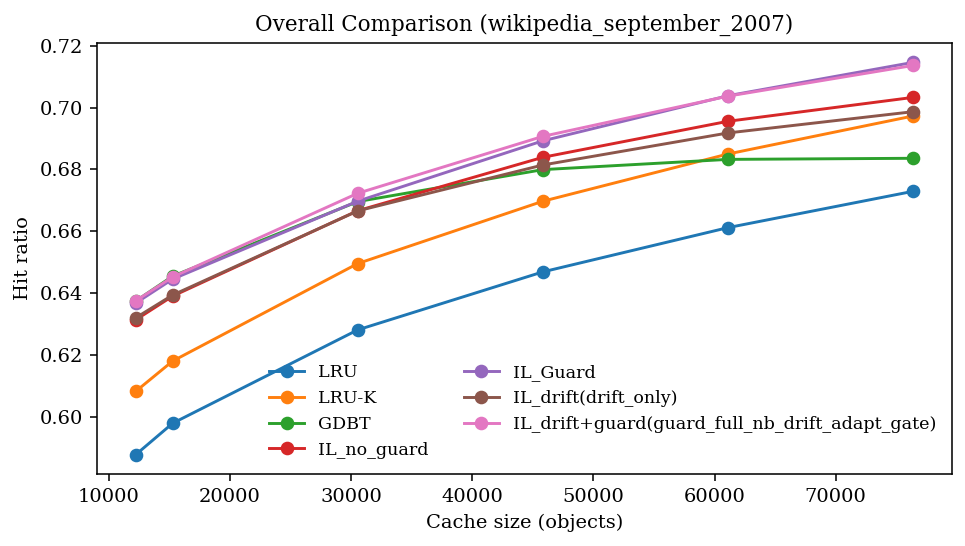

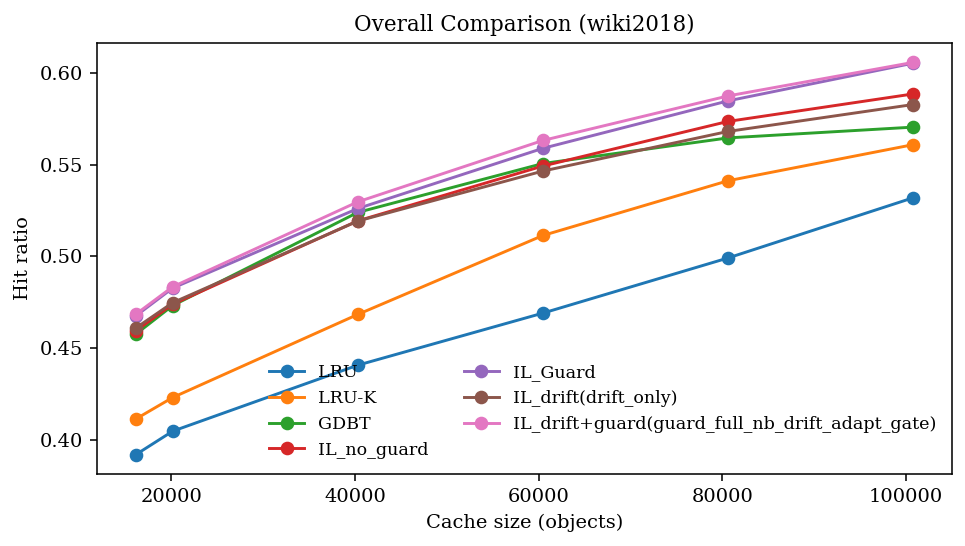

In [5]:
# Plot overall comparison per dataset

method_order = [
    'LRU', 'LRU-K', 'GDBT',
    'IL_no_guard', 'IL_Guard'
]

for dataset in DATASETS.keys():
    data = combined[combined['dataset'] == dataset].copy()
    drift_methods = sorted([m for m in data['method'].unique() if m.startswith('IL_drift(')])
    drift_guard_methods = sorted([m for m in data['method'].unique() if m.startswith('IL_drift+guard(')])
    plot_methods = method_order + drift_methods + drift_guard_methods

    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    for method in plot_methods:
        g = data[data['method'] == method]
        if g.empty:
            continue
        g = g.sort_values('cache_size')
        ax.plot(g['cache_size'], g['hit_ratio'], marker='o', label=method)

    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Hit ratio')
    ax.set_title(f'Overall Comparison ({dataset})')
    ax.legend(loc='best', frameon=False, ncol=2)
    fig.tight_layout()

    fig.savefig(FIG_DIR / f'overall_comparison_{dataset}.png')
    fig.savefig(FIG_DIR / f'overall_comparison_{dataset}.pdf')
    plt.show()
    plt.close(fig)



In [6]:
# Show which variants were selected as best drift and best drift+guard
for dataset, root in DATASETS.items():
    il_df = collect_il_variants(root, FEATURE_SET)
    best_drift, _ = pick_best_variant(
        il_df,
        include_pred=lambda v: v.startswith('drift_') or v == 'drift_only',
        exclude_pred=lambda v: 'guard' in v
    )
    best_dg, _ = pick_best_variant(
        il_df,
        include_pred=lambda v: ('guard' in v) and ('drift' in v),
        exclude_pred=None
    )
    print(dataset, 'best drift =', best_drift, '| best drift+guard =', best_dg)



wikipedia_september_2007 best drift = drift_only | best drift+guard = guard_full_nb_drift_adapt_gate
wiki2018 best drift = drift_only | best drift+guard = guard_full_nb_drift_adapt_gate


In [7]:
# % HR improvement of IL_Guard vs IL_no_guard (per size + average)

rows = []
for dataset, root in DATASETS.items():
    # load IL summaries for guard and no-guard
    def load_summary(variant, size):
        p = root / f"{RUN_PREFIX}_summary_ilnse_{FEATURE_SET}_{variant}_{size}.json"
        with p.open() as f:
            return json.load(f)

    # list sizes from guard variant
    sizes = set()
    for p in root.glob(f"{RUN_PREFIX}_summary_ilnse_{FEATURE_SET}_guard_full_NB_*.json"):
        try:
            sizes.add(int(p.stem.split('_')[-1]))
        except Exception:
            pass
    sizes = sorted(sizes)

    for size in sizes:
        s_full = load_summary('guard_full_NB', size)
        s_nog = load_summary('guard_no_guard_NB', size)
        hr_full = s_full.get('hit_ratio')
        hr_nog = s_nog.get('hit_ratio')
        if hr_nog is None or hr_nog == 0:
            continue
        delta = hr_full - hr_nog
        delta_pct = delta / hr_nog * 100.0
        rows.append({
            'dataset': dataset,
            'cache_size': size,
            'hr_guard': hr_full,
            'hr_no_guard': hr_nog,
            'delta_hr': delta,
            'delta_hr_pct': delta_pct,
        })

hr_delta = pd.DataFrame(rows)
hr_delta_sorted = hr_delta.sort_values(['dataset','cache_size'])

# Average % per dataset
avg_pct = hr_delta.groupby('dataset')['delta_hr_pct'].mean().reset_index()
avg_pct = avg_pct.rename(columns={'delta_hr_pct': 'avg_delta_hr_pct'})

# Save tables
hr_delta_sorted.to_csv(TAB_DIR / 'overall_guard_vs_noguard_delta_pct.csv', index=False)
hr_delta_sorted.to_latex(TAB_DIR / 'overall_guard_vs_noguard_delta_pct.tex', index=False, float_format='%.6f')

avg_pct.to_csv(TAB_DIR / 'overall_guard_vs_noguard_avg_delta_pct.csv', index=False)
avg_pct.to_latex(TAB_DIR / 'overall_guard_vs_noguard_avg_delta_pct.tex', index=False, float_format='%.6f')

hr_delta_sorted.head(), avg_pct



/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_45402/150299223.py:47: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  hr_delta_sorted.to_latex(TAB_DIR / 'overall_guard_vs_noguard_delta_pct.tex', index=False, float_format='%.6f')
/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_45402/150299223.py:50: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  avg_pct.to_latex(TAB_DIR / 'overall_guard_vs_noguard_avg_delta_pct.tex', index=False, float_format='%.6f')


(     dataset  cache_size  hr_guard  hr_no_guard  delta_hr  delta_hr_pct
 6   wiki2018       16123  0.467573     0.459428  0.008145      1.772808
 7   wiki2018       20154  0.482762     0.473951  0.008811      1.859099
 8   wiki2018       40308  0.526069     0.519354  0.006715      1.293017
 9   wiki2018       60463  0.558828     0.549192  0.009636      1.754618
 10  wiki2018       80617  0.584645     0.573466  0.011179      1.949355,
                     dataset  avg_delta_hr_pct
 0                  wiki2018          1.912102
 1  wikipedia_september_2007          0.960160)